In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set()

# EDA — Dataset Pima Indians Diabetes
**Aprendizaje de Máquina - CEIA - FIUBA**

*Notebook optativa*

Este dataset proviene del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales de los Estados Unidos. Contiene datos clínicos de **768 mujeres de la comunidad Pima** (una comunidad indígena del sur de Arizona con alta incidencia de diabetes tipo 2), con el objetivo de predecir si una paciente tiene diabetes o no a partir de medidas diagnósticas.

## Variables

| Feature | Descripción | Unidad |
|---|---|---|
| `embarazos` | Número de embarazos | — |
| `glucosa` | Concentración de glucosa en plasma (prueba oral de tolerancia a la glucosa, 2h) | mg/dL |
| `presion_arterial` | Presión arterial diastólica | mm Hg |
| `grosor_piel` | Grosor del pliegue cutáneo del tríceps | mm |
| `insulina` | Insulina sérica a las 2 horas | mu U/ml |
| `imc` | Índice de masa corporal | kg/m² |
| `funcion_pedigri` | Función de pedigri de la diabetes (indicador de historial familiar) | — |
| `edad` | Edad | años |
| `diabetes` | Diagnóstico (0 = sin diabetes, 1 = con diabetes) | — |

In [2]:
pima_df = pd.read_csv("./datasets/pima_diabetes.csv")

# Columna con etiquetas legibles para graficar
pima_df["diagnostico"] = pima_df["diabetes"].map({0: "Sin diabetes", 1: "Con diabetes"})

pima_df.head()

,embarazos,glucosa,presion_arterial,grosor_piel,insulina,imc,funcion_pedigri,edad,diabetes,diagnostico
0,6,148,72,35,0,33.6,0.627,50,1,Con diabetes
1,1,85,66,29,0,26.6,0.351,31,0,Sin diabetes
2,8,183,64,0,0,23.3,0.672,32,1,Con diabetes
3,1,89,66,23,94,28.1,0.167,21,0,Sin diabetes
4,0,137,40,35,168,43.1,2.288,33,1,Con diabetes


In [3]:
print(f"Dimensiones: {pima_df.shape[0]} filas × {pima_df.shape[1] - 2} ", 
    "features + 1 target")
print()
pima_df.drop(columns="diagnostico").info()

Dimensiones: 768 filas × 8  features + 1 target

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   embarazos         768 non-null    int64  
 1   glucosa           768 non-null    int64  
 2   presion_arterial  768 non-null    int64  
 3   grosor_piel       768 non-null    int64  
 4   insulina          768 non-null    int64  
 5   imc               768 non-null    float64
 6   funcion_pedigri   768 non-null    float64
 7   edad              768 non-null    int64  
 8   diabetes          768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
pima_df.drop(columns="diagnostico").describe()

,embarazos,glucosa,presion_arterial,grosor_piel,insulina,imc,funcion_pedigri,edad,diabetes
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Distribución de la variable objetivo

El dataset presenta un **desbalance de clases moderado**: hay aproximadamente el doble de observaciones negativas que positivas. Esto es relevante al momento de elegir métricas de evaluación — la exactitud (accuracy) puede ser engañosa; conviene usar F1-score o exactitud balanceada.

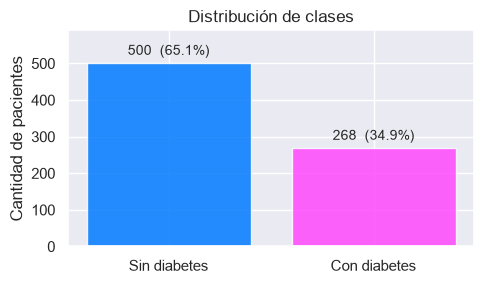

In [5]:
conteo = pima_df["diagnostico"].value_counts()
colores_clase = {"Sin diabetes": "#007aff", "Con diabetes": "#ff48fd"}

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(
    conteo.index,
    conteo.values,
    color=[colores_clase[k] for k in conteo.index],
    alpha=0.85,
)
ax.bar_label(
    bars,
    labels=[f"{v}  ({v / len(pima_df) * 100:.1f}%)" for v in conteo.values],
    padding=4,
    fontsize=10,
)
ax.set_ylabel("Cantidad de pacientes")
ax.set_title("Distribución de clases")
ax.set_ylim(0, conteo.max() * 1.18)
plt.tight_layout()
plt.show()

## Distribuciones de cada feature por clase

Visualizamos la distribución de cada variable separada por diagnóstico. Esto nos permite identificar rápidamente cuáles features tienen mayor **poder discriminativo** — es decir, cuáles se ven más diferentes entre las dos clases.

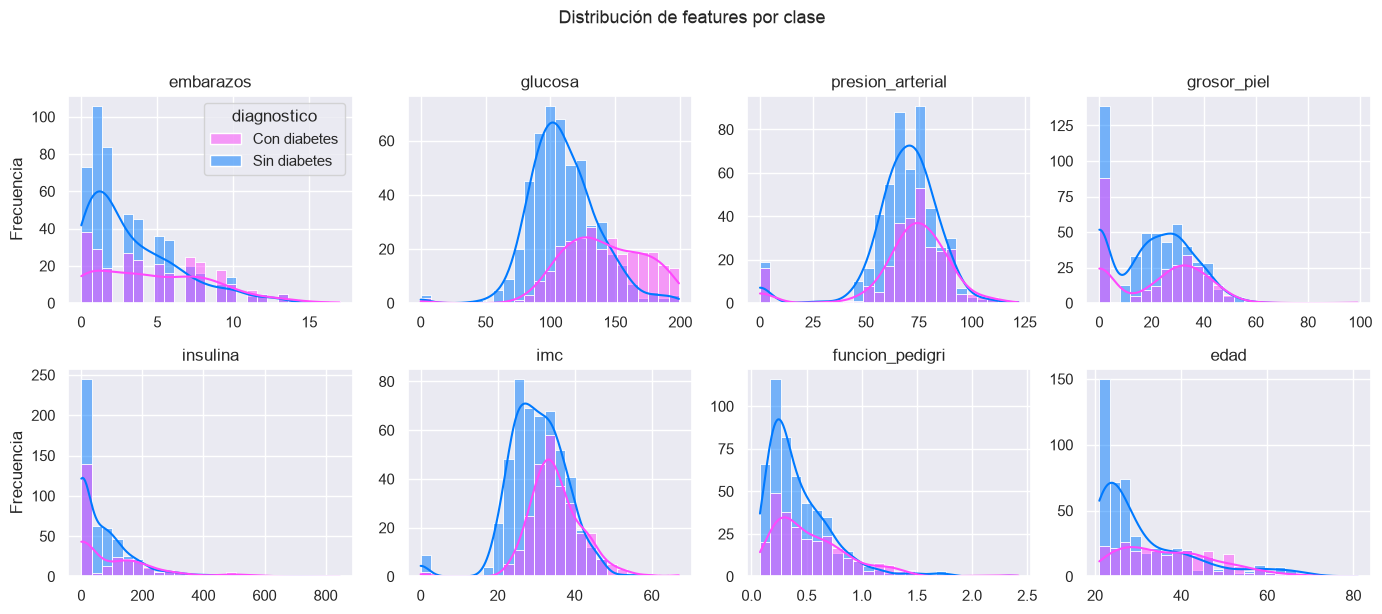

In [6]:
features = [
    "embarazos", "glucosa", "presion_arterial", "grosor_piel",
    "insulina", "imc", "funcion_pedigri", "edad",
]

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.ravel()

for i, feat in enumerate(features):
    sns.histplot(
        data=pima_df,
        x=feat,
        hue="diagnostico",
        palette=colores_clase,
        kde=True,
        alpha=0.5,
        bins=25,
        ax=axes[i],
        legend=(i == 0),
    )
    axes[i].set_title(feat)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frecuencia" if i % 4 == 0 else "")

plt.suptitle("Distribución de features por clase", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

Los histogramas revelan que:
- **`glucosa`** es la variable con mayor separación entre clases: valores altos se asocian claramente con diabetes.
- **`imc`** y **`edad`** también muestran diferencias visibles.
- **`insulina`** y **`grosor_piel`** tienen una masa concentrada en cero — esto no es un valor real sino un indicador de dato ausente (ver siguiente sección).

---
## Valores cero — datos ausentes enmascarados

Un aspecto crítico de este dataset es que varios features contienen **ceros que son biológicamente imposibles**:

- `glucosa = 0`: imposible (una glucosa de 0 mg/dL sería incompatible con la vida)
- `presion_arterial = 0`: imposible
- `imc = 0`: imposible
- `grosor_piel = 0` e `insulina = 0`: plausibles en algunos casos, pero estadísticamente sospechosos

Estos ceros representan **valores faltantes** que fueron codificados como 0 en el dataset original. Es importante identificarlos — y decidir cómo tratarlos — antes de entrenar cualquier modelo.

In [7]:
features_con_ceros_sospechosos = [
    "glucosa", "presion_arterial", "grosor_piel", "insulina", "imc"
]

df_ceros = pd.DataFrame({
    "Ceros": [(pima_df[f] == 0).sum() for f in features_con_ceros_sospechosos],
    "% del total": [(pima_df[f] == 0).sum() / len(pima_df) * 100 for f in 
        features_con_ceros_sospechosos],
}, index=features_con_ceros_sospechosos)

df_ceros.round(1)

,Ceros,% del total
glucosa,5,0.7
presion_arterial,35,4.6
grosor_piel,227,29.6
insulina,374,48.7
imc,11,1.4


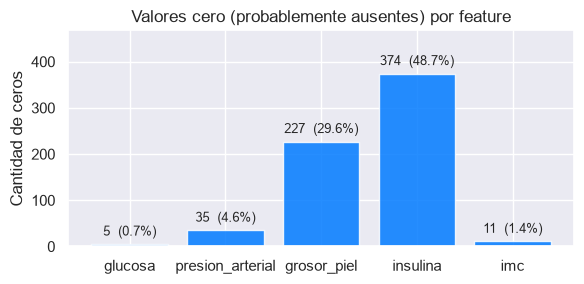

In [8]:
fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.bar(df_ceros.index, df_ceros["Ceros"], color="#007aff", alpha=0.85)
ax.bar_label(
    bars,
    labels=[f"{int(v)}  ({p:.1f}%)" for v, p in zip(df_ceros["Ceros"], 
    df_ceros["% del total"])],
    padding=4,
    fontsize=9,
)
ax.set_ylabel("Cantidad de ceros")
ax.set_title("Valores cero (probablemente ausentes) por feature")
ax.set_ylim(0, df_ceros["Ceros"].max() * 1.25)
plt.tight_layout()
plt.show()

`insulina` tiene casi la mitad de sus valores en cero (48.7%), lo que la hace prácticamente inutilizable sin imputación. `grosor_piel` también está muy afectada (29.6%).

---
## Correlación entre features

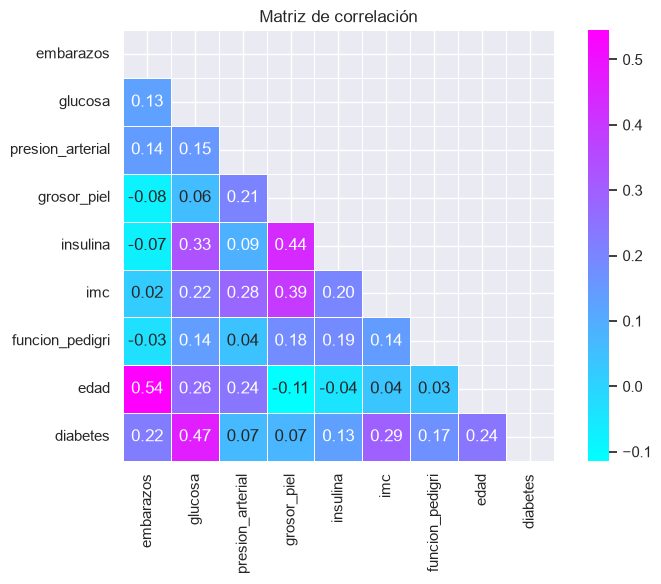

In [9]:
corr = pima_df.drop(columns="diagnostico").corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="cool",
    cbar=True,
    ax=ax,
    square=True,
    linewidths=0.5,
)
ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

No hay correlaciones extremadamente altas entre features, lo que es una buena señal para modelos de ML (menor riesgo de multicolinealidad). Las correlaciones más notables son:
- `edad` ↔ `embarazos` (0.54): lógico, más edad implica más posibilidad de haber tenido embarazos.
- `grosor_piel` ↔ `imc` (0.39): ambas miden adiposidad.
- `glucosa` ↔ `diabetes` (0.47): la correlación más alta con el target — confirma que es el predictor más relevante.

---
## Pairplot

Visualización completa de las relaciones por pares entre todas las variables, coloreadas por diagnóstico.

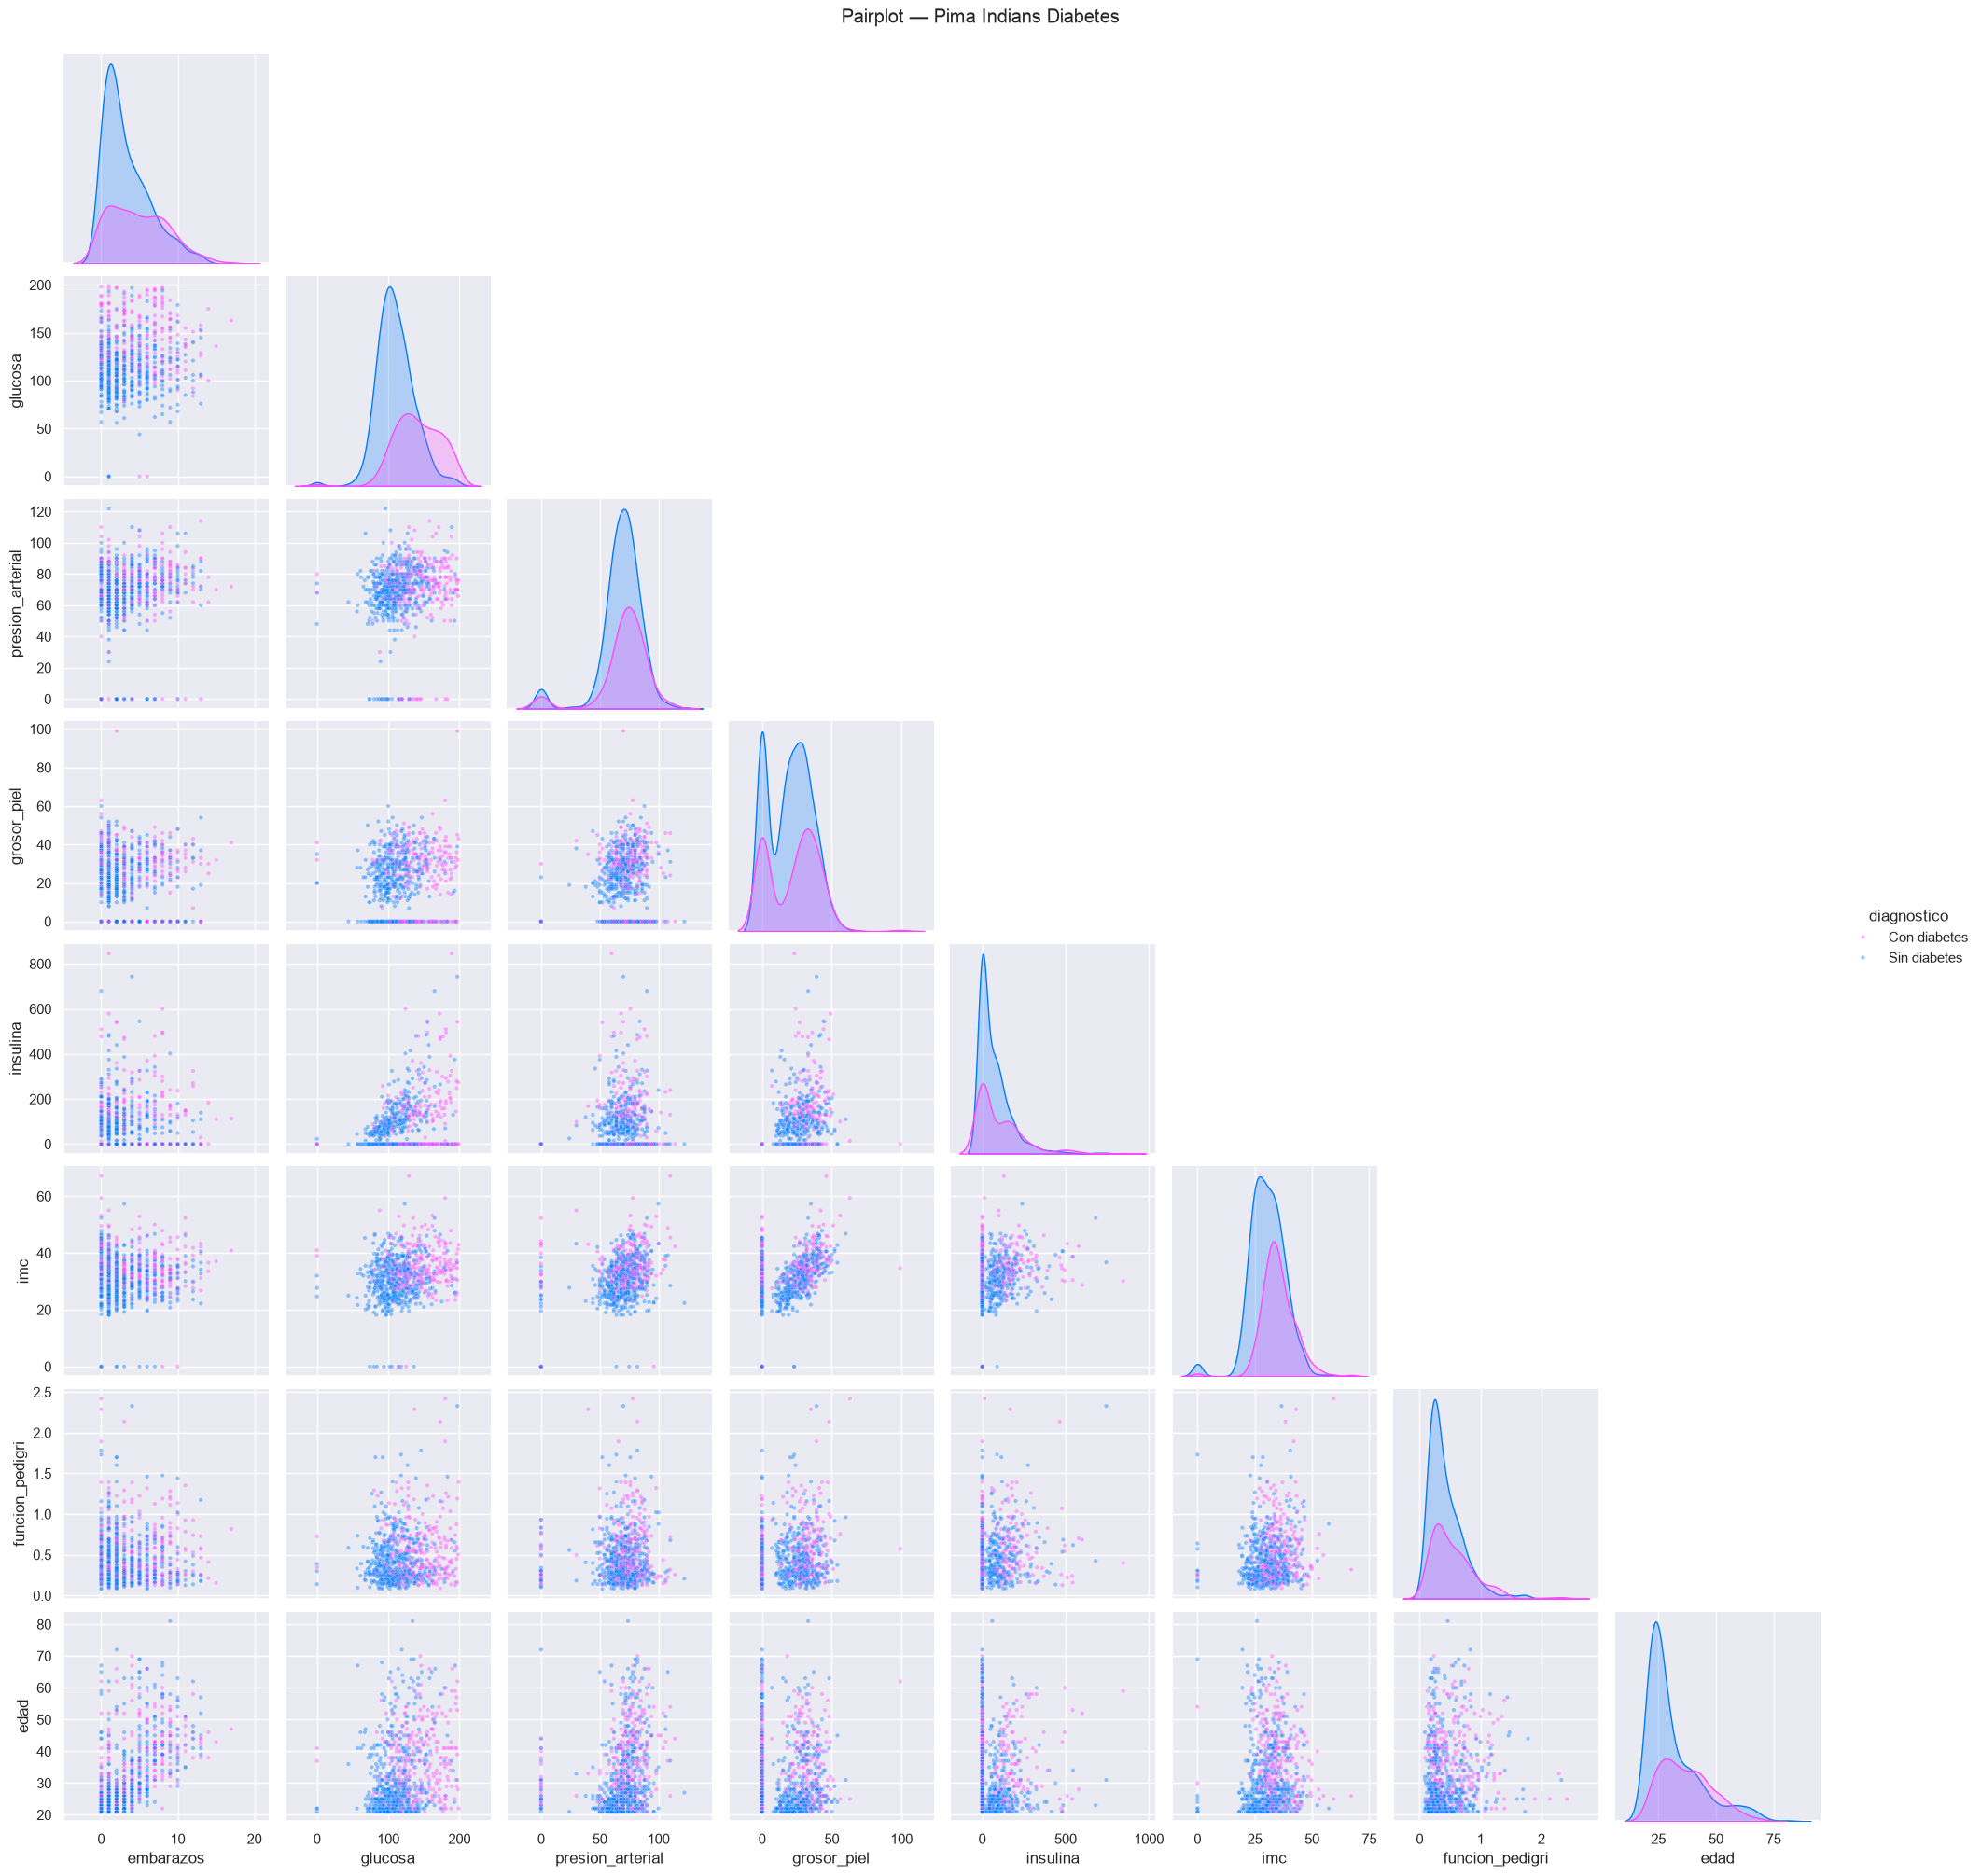

In [10]:
g = sns.pairplot(
    pima_df.drop(columns="diabetes"),
    hue="diagnostico",
    palette=colores_clase,
    plot_kws={"alpha": 0.4, "s": 10},
    diag_kind="kde",
    corner=True,
)
g.figure.suptitle("Pairplot — Pima Indians Diabetes", y=1.01)
plt.show()

---
## Observaciones clave

1. **`glucosa`** es el predictor más poderoso: su distribución difiere notablemente entre clases y tiene la correlación más alta con el target.
2. **`imc`** y **`edad`** también son buenos predictores.
3. **`insulina`** y **`grosor_piel`** tienen muchos valores ausentes enmascarados como ceros. Usarlos sin preprocesamiento puede degradar el modelo.
4. El dataset está **moderadamente desbalanceado** (65% / 35%). Se recomienda usar F1-score o exactitud balanceada como métricas principales, no accuracy.
5. Las correlaciones entre features son moderadas — no hay redundancia severa, lo que facilita la interpretación y el entrenamiento de modelos.